# Notebook 2 — Preprocessing and Data Pipeline

Denne notebooken gjør fem ting:

1. Leser inn metadata fra CheXpert
2. Velger labels og strategi for uncertain labels
3. Filtrerer og renser train/valid-data
4. Bygger en `tf.data` pipeline for bilde- og label-loading
5. Kjører sanity checks før modelltrening

Mål:
Å lage en ryddig, reproduserbar pipeline som kan brukes videre i baseline-CNN og DenseNet-121.

In [64]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive

In [66]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Num GPUs available:", len(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.19.0
Num GPUs available: 0


In [67]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
PROJECT_ROOT = Path("/content/drive/MyDrive/DAT255_CheXpert_Project")
SESSION_ROOT = Path("/content/dat255_chexpert")

DIRS = {
    "project_root": PROJECT_ROOT,
    "session_root": SESSION_ROOT,
    "raw_data": SESSION_ROOT / "data" / "raw",
    "processed_data": PROJECT_ROOT / "data" / "processed",
    "cache": PROJECT_ROOT / "data" / "cache",
    "models": PROJECT_ROOT / "models",
    "results": PROJECT_ROOT / "results",
    "figures": PROJECT_ROOT / "figures",
    "reports": PROJECT_ROOT / "reports",
    "notebooks": PROJECT_ROOT / "notebooks",
    "src": PROJECT_ROOT / "src",
}

for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

for name, p in DIRS.items():
    print(f"{name}: {p}")

project_root: /content/drive/MyDrive/DAT255_CheXpert_Project
session_root: /content/dat255_chexpert
raw_data: /content/dat255_chexpert/data/raw
processed_data: /content/drive/MyDrive/DAT255_CheXpert_Project/data/processed
cache: /content/drive/MyDrive/DAT255_CheXpert_Project/data/cache
models: /content/drive/MyDrive/DAT255_CheXpert_Project/models
results: /content/drive/MyDrive/DAT255_CheXpert_Project/results
figures: /content/drive/MyDrive/DAT255_CheXpert_Project/figures
reports: /content/drive/MyDrive/DAT255_CheXpert_Project/reports
notebooks: /content/drive/MyDrive/DAT255_CheXpert_Project/notebooks
src: /content/drive/MyDrive/DAT255_CheXpert_Project/src


In [69]:
CONFIG = {
    "seed": 42,
    "image_size": 224,
    "image_channels": 3,
    "batch_size": 16,
    "autotune": tf.data.AUTOTUNE,
    "use_frontal_only": True,
    "uncertainty_strategy": "U-Ones",   # bytt senere til "U-Zeroes" for sammenligning
    "label_mode": "competition_5",      # "competition_5" eller "all_14"
    "project_root": str(DIRS["project_root"]),
    "session_root": str(DIRS["session_root"]),
    "raw_data_root": str(DIRS["raw_data"]),
    "processed_data_root": str(DIRS["processed_data"]),
    "cache_root": str(DIRS["cache"]),
    "models_root": str(DIRS["models"]),
    "results_root": str(DIRS["results"]),
    "figures_root": str(DIRS["figures"]),
    "reports_root": str(DIRS["reports"]),
    "all_labels": [
        "No Finding",
        "Enlarged Cardiomediastinum",
        "Cardiomegaly",
        "Lung Opacity",
        "Lung Lesion",
        "Edema",
        "Consolidation",
        "Pneumonia",
        "Atelectasis",
        "Pneumothorax",
        "Pleural Effusion",
        "Pleural Other",
        "Fracture",
        "Support Devices",
    ],
    "competition_labels": [
        "Atelectasis",
        "Cardiomegaly",
        "Consolidation",
        "Edema",
        "Pleural Effusion",
    ],
}

print(json.dumps(CONFIG, indent=2, default=str))

{
  "seed": 42,
  "image_size": 224,
  "image_channels": 3,
  "batch_size": 16,
  "autotune": -1,
  "use_frontal_only": true,
  "uncertainty_strategy": "U-Ones",
  "label_mode": "competition_5",
  "project_root": "/content/drive/MyDrive/DAT255_CheXpert_Project",
  "session_root": "/content/dat255_chexpert",
  "raw_data_root": "/content/dat255_chexpert/data/raw",
  "processed_data_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/data/processed",
  "cache_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/data/cache",
  "models_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/models",
  "results_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/results",
  "figures_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/figures",
  "reports_root": "/content/drive/MyDrive/DAT255_CheXpert_Project/reports",
  "all_labels": [
    "No Finding",
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
   

In [70]:
def ensure_chexpert_dataset(raw_data_root: Path):
    raw_data_root = Path(raw_data_root)
    train_csv = raw_data_root / "train.csv"
    valid_csv = raw_data_root / "valid.csv"

    if train_csv.exists() and valid_csv.exists():
        print("CheXpert already available at:", raw_data_root)
        return raw_data_root

    print("CheXpert not found locally. Downloading from KaggleHub...")
    import kagglehub

    downloaded_path = Path(kagglehub.dataset_download("ashery/chexpert"))
    print("Downloaded to:", downloaded_path)

    if (downloaded_path / "train.csv").exists():
        source_root = downloaded_path
    else:
        candidates = list(downloaded_path.rglob("train.csv"))
        if not candidates:
            raise FileNotFoundError("Could not find train.csv in downloaded dataset.")
        source_root = candidates[0].parent

    print("Using source root:", source_root)

    raw_data_root.mkdir(parents=True, exist_ok=True)

    for item in source_root.iterdir():
        target = raw_data_root / item.name
        if target.exists():
            continue
        try:
            os.symlink(item, target)
        except Exception:
            import shutil
            if item.is_dir():
                shutil.copytree(item, target)
            else:
                shutil.copy2(item, target)

    if not train_csv.exists() or not valid_csv.exists():
        raise FileNotFoundError("train.csv / valid.csv not found after setup.")

    print("CheXpert ready at:", raw_data_root)
    return raw_data_root


DATA_ROOT = ensure_chexpert_dataset(Path(CONFIG["raw_data_root"]))
print("DATA_ROOT =", DATA_ROOT)

CheXpert already available at: /content/dat255_chexpert/data/raw
DATA_ROOT = /content/dat255_chexpert/data/raw


In [71]:
train_df = pd.read_csv(DATA_ROOT / "train.csv")
valid_df = pd.read_csv(DATA_ROOT / "valid.csv")

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

train_df.head()

Train shape: (223414, 19)
Valid shape: (234, 19)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [72]:
if CONFIG["label_mode"] == "competition_5":
    TARGET_LABELS = CONFIG["competition_labels"]
elif CONFIG["label_mode"] == "all_14":
    TARGET_LABELS = CONFIG["all_labels"]
else:
    raise ValueError("label_mode must be 'competition_5' or 'all_14'")

print("Using labels:")
for label in TARGET_LABELS:
    print("-", label)

Using labels:
- Atelectasis
- Cardiomegaly
- Consolidation
- Edema
- Pleural Effusion


In [73]:
def filter_by_view(df, use_frontal_only=True):
    df = df.copy()
    if not use_frontal_only:
        return df

    frontal_views = ["AP", "PA"]
    if "Frontal/Lateral" in df.columns:
        df = df[df["Frontal/Lateral"] == "Frontal"].copy()
    elif "AP/PA" in df.columns:
        df = df[df["AP/PA"].isin(frontal_views)].copy()

    return df

In [74]:
def apply_uncertainty_strategy(df, labels, strategy="U-Ones"):
    df = df.copy()

    for label in labels:
        df[label] = pd.to_numeric(df[label], errors="coerce")

        if strategy == "U-Ones":
            df[label] = df[label].replace(-1, 1)
        elif strategy == "U-Zeroes":
            df[label] = df[label].replace(-1, 0)
        elif strategy == "U-Ignore":
            pass
        else:
            raise ValueError("strategy must be 'U-Ones', 'U-Zeroes', or 'U-Ignore'")

    return df

In [75]:
def clean_label_dataframe(df, labels, uncertainty_strategy="U-Ones"):
    df = df.copy()

    # Filtrer frontal først hvis ønskelig
    df = filter_by_view(df, use_frontal_only=CONFIG["use_frontal_only"])

    # Gjør labels numeriske og håndter uncertainty
    df = apply_uncertainty_strategy(df, labels, strategy=uncertainty_strategy)

    if uncertainty_strategy == "U-Ignore":
        # Fjern rader der minst én target-label er uncertain (-1)
        for label in labels:
            df = df[df[label] != -1]

    # Fyll manglende labels med 0
    for label in labels:
        df[label] = pd.to_numeric(df[label], errors="coerce").fillna(0)

    # Klipp til 0/1
    for label in labels:
        df[label] = df[label].clip(0, 1).astype(np.float32)

    # Fjern rader uten gyldig path
    df = df[df["Path"].notna()].copy()

    df.reset_index(drop=True, inplace=True)
    return df

In [76]:
train_clean = clean_label_dataframe(
    train_df,
    labels=TARGET_LABELS,
    uncertainty_strategy=CONFIG["uncertainty_strategy"]
)

valid_clean = clean_label_dataframe(
    valid_df,
    labels=TARGET_LABELS,
    uncertainty_strategy=CONFIG["uncertainty_strategy"]
)

print("Cleaned train shape:", train_clean.shape)
print("Cleaned valid shape:", valid_clean.shape)

train_clean[TARGET_LABELS].head()

Cleaned train shape: (191027, 19)
Cleaned valid shape: (202, 19)


,Atelectasis,Cardiomegaly,Consolidation,Edema,Pleural Effusion
0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,1.0
2,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0


In [77]:
train_positive_counts = train_clean[TARGET_LABELS].sum().sort_values(ascending=False)
valid_positive_counts = valid_clean[TARGET_LABELS].sum().sort_values(ascending=False)

display(train_positive_counts)
display(valid_positive_counts)

,0
Pleural Effusion,86477.0
Edema,61493.0
Atelectasis,59583.0
Consolidation,37364.0
Cardiomegaly,30092.0


,0
Atelectasis,75.0
Cardiomegaly,66.0
Pleural Effusion,64.0
Edema,42.0
Consolidation,32.0


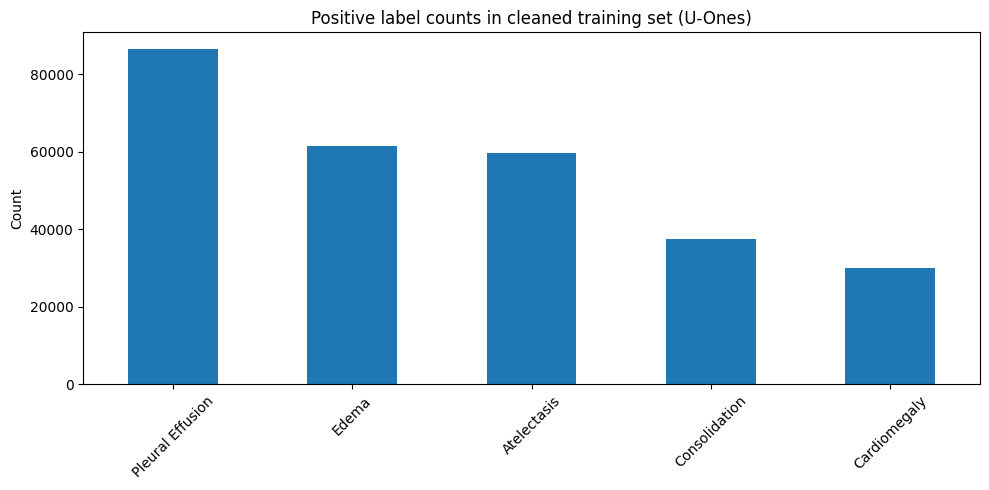

In [78]:
plt.figure(figsize=(10, 5))
train_positive_counts.plot(kind="bar")
plt.title(f"Positive label counts in cleaned training set ({CONFIG['uncertainty_strategy']})")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
processed_root = Path(CONFIG["processed_data_root"])

train_clean_path = processed_root / f"train_clean_{CONFIG['label_mode']}_{CONFIG['uncertainty_strategy']}.csv"
valid_clean_path = processed_root / f"valid_clean_{CONFIG['label_mode']}_{CONFIG['uncertainty_strategy']}.csv"

train_clean.to_csv(train_clean_path, index=False)
valid_clean.to_csv(valid_clean_path, index=False)

print("Saved train_clean to:", train_clean_path)
print("Saved valid_clean to:", valid_clean_path)

Saved train_clean to: /content/drive/MyDrive/DAT255_CheXpert_Project/data/processed/train_clean_competition_5_U-Ones.csv
Saved valid_clean to: /content/drive/MyDrive/DAT255_CheXpert_Project/data/processed/valid_clean_competition_5_U-Ones.csv


In [80]:
def make_absolute_image_path(rel_path: str, data_root: Path) -> str:
    rel_path = str(rel_path).strip()
    data_root = Path(data_root)

    # Kandidat 1
    candidate_1 = data_root / rel_path
    if candidate_1.exists():
        return str(candidate_1)

    # Fjern dataset-prefix hvis det finnes
    prefixes = [
        "CheXpert-v1.0-small/",
        "CheXpert-v1.0/"
    ]

    for prefix in prefixes:
        if rel_path.startswith(prefix):
            stripped = rel_path[len(prefix):]
            candidate_2 = data_root / stripped
            if candidate_2.exists():
                return str(candidate_2)

    # Kandidat 3
    candidate_3 = data_root.parent / rel_path
    if candidate_3.exists():
        return str(candidate_3)

    return str(candidate_1)

In [81]:
train_clean["image_path"] = train_clean["Path"].apply(lambda x: make_absolute_image_path(x, DATA_ROOT))
valid_clean["image_path"] = valid_clean["Path"].apply(lambda x: make_absolute_image_path(x, DATA_ROOT))

train_clean["label_vector"] = train_clean[TARGET_LABELS].values.tolist()
valid_clean["label_vector"] = valid_clean[TARGET_LABELS].values.tolist()

train_clean[["Path", "image_path"] + TARGET_LABELS[:3]].head()

,Path,image_path,Atelectasis,Cardiomegaly,Consolidation
0,CheXpert-v1.0-small/train/patient00001/study1/...,/content/dat255_chexpert/data/raw/train/patien...,0.0,0.0,0.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,/content/dat255_chexpert/data/raw/train/patien...,1.0,1.0,1.0
2,CheXpert-v1.0-small/train/patient00002/study1/...,/content/dat255_chexpert/data/raw/train/patien...,0.0,0.0,1.0
3,CheXpert-v1.0-small/train/patient00003/study1/...,/content/dat255_chexpert/data/raw/train/patien...,0.0,0.0,0.0
4,CheXpert-v1.0-small/train/patient00004/study1/...,/content/dat255_chexpert/data/raw/train/patien...,0.0,0.0,0.0


In [82]:
def file_exists(path):
    return Path(path).exists()

train_clean["file_exists"] = train_clean["image_path"].apply(file_exists)
valid_clean["file_exists"] = valid_clean["image_path"].apply(file_exists)

print("Train existing files ratio:", train_clean["file_exists"].mean())
print("Valid existing files ratio:", valid_clean["file_exists"].mean())

print("\nExample train paths:")
display(train_clean[["Path", "image_path", "file_exists"]].head(10))

print("\nMissing train files examples:")
display(train_clean.loc[~train_clean["file_exists"], ["Path", "image_path"]].head(10))

Train existing files ratio: 1.0
Valid existing files ratio: 1.0

Example train paths:


,Path,image_path,file_exists
0,CheXpert-v1.0-small/train/patient00001/study1/...,/content/dat255_chexpert/data/raw/train/patien...,True
1,CheXpert-v1.0-small/train/patient00002/study2/...,/content/dat255_chexpert/data/raw/train/patien...,True
2,CheXpert-v1.0-small/train/patient00002/study1/...,/content/dat255_chexpert/data/raw/train/patien...,True
3,CheXpert-v1.0-small/train/patient00003/study1/...,/content/dat255_chexpert/data/raw/train/patien...,True
4,CheXpert-v1.0-small/train/patient00004/study1/...,/content/dat255_chexpert/data/raw/train/patien...,True
5,CheXpert-v1.0-small/train/patient00005/study1/...,/content/dat255_chexpert/data/raw/train/patien...,True
6,CheXpert-v1.0-small/train/patient00005/study2/...,/content/dat255_chexpert/data/raw/train/patien...,True
7,CheXpert-v1.0-small/train/patient00005/study2/...,/content/dat255_chexpert/data/raw/train/patien...,True
8,CheXpert-v1.0-small/train/patient00006/study1/...,/content/dat255_chexpert/data/raw/train/patien...,True
9,CheXpert-v1.0-small/train/patient00007/study1/...,/content/dat255_chexpert/data/raw/train/patien...,True



Missing train files examples:


,Path,image_path


In [92]:
train_clean = train_clean[train_clean["file_exists"]].reset_index(drop=True)
valid_clean = valid_clean[valid_clean["file_exists"]].reset_index(drop=True)

print("Train shape after file check:", train_clean.shape)
print("Valid shape after file check:", valid_clean.shape)

if len(train_clean) == 0:
    raise ValueError("train_clean is empty after file check. Image paths are wrong.")

if len(valid_clean) == 0:
    raise ValueError("valid_clean is empty after file check. Image paths are wrong.")

Train shape after file check: (191027, 22)
Valid shape after file check: (202, 22)


In [87]:
IMG_SIZE = CONFIG["image_size"]

def decode_and_resize_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [95]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.05),
], name="data_augmentation")

In [89]:
def apply_train_augmentation(image, label):
    image = data_augmentation(image, training=True)
    return image, label

In [96]:
BATCH_SIZE = CONFIG["batch_size"]
AUTOTUNE = tf.data.AUTOTUNE

train_paths = train_clean["image_path"].astype(str).values
train_labels = np.stack(train_clean["label_vector"].values).astype(np.float32)

valid_paths = valid_clean["image_path"].astype(str).values
valid_labels = np.stack(valid_clean["label_vector"].values).astype(np.float32)

print("Train samples:", len(train_paths))
print("Valid samples:", len(valid_paths))
print("Train labels shape:", train_labels.shape)
print("Valid labels shape:", valid_labels.shape)

if len(train_paths) == 0:
    raise ValueError("train_paths is empty. Check image_path creation.")

if len(valid_paths) == 0:
    raise ValueError("valid_paths is empty. Check image_path creation.")

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
valid_ds = tf.data.Dataset.from_tensor_slices((valid_paths, valid_labels))

train_ds = (
    train_ds
    .shuffle(buffer_size=min(len(train_paths), 10000), seed=CONFIG["seed"])
    .map(decode_and_resize_image, num_parallel_calls=AUTOTUNE)
    .map(apply_train_augmentation, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

valid_ds = (
    valid_ds
    .map(decode_and_resize_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Train dataset built.")
print("Valid dataset built.")

Train samples: 191027
Valid samples: 202
Train labels shape: (191027, 5)
Valid labels shape: (202, 5)
Train dataset built.
Valid dataset built.


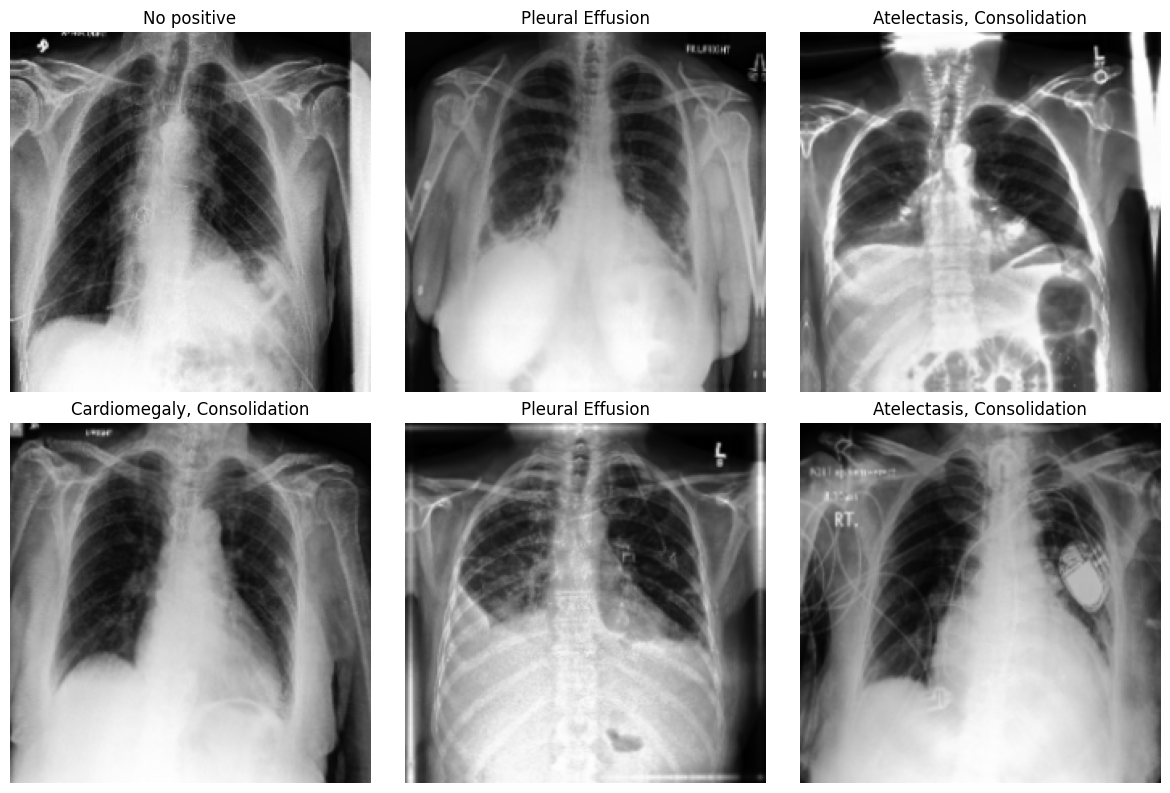

In [103]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(6, images.shape[0])):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())

        positive_labels = [
            TARGET_LABELS[j]
            for j, v in enumerate(labels[i].numpy())
            if v > 0.5
        ]

        plt.title(", ".join(positive_labels[:2]) if positive_labels else "No positive")
        plt.axis("off")

plt.tight_layout()
plt.savefig(
    Path(CONFIG["figures_root"]) / "dataset_samples.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## Lagring i disk

In [106]:
config_out = Path(CONFIG["results_root"]) / "config_notebook2.json"

with open(config_out, "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Saved config to:", config_out)

Saved config to: /content/drive/MyDrive/DAT255_CheXpert_Project/results/config_notebook2.json


In [105]:
summary_df = pd.DataFrame({
    "split": ["train", "valid"],
    "num_samples": [len(train_clean), len(valid_clean)],
    "label_mode": [CONFIG["label_mode"], CONFIG["label_mode"]],
    "uncertainty_strategy": [CONFIG["uncertainty_strategy"], CONFIG["uncertainty_strategy"]],
    "use_frontal_only": [CONFIG["use_frontal_only"], CONFIG["use_frontal_only"]],
})

summary_path = Path(CONFIG["results_root"]) / "dataset_summary_notebook2.csv"
summary_df.to_csv(summary_path, index=False)

summary_df

,split,num_samples,label_mode,uncertainty_strategy,use_frontal_only
0,train,191027,competition_5,U-Ones,True
1,valid,202,competition_5,U-Ones,True


In [104]:
plt.savefig(
    Path(CONFIG["figures_root"]) / "label_distribution_train.png",
    dpi=200,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>